1. CLUSTERING + CLASSIFICATION

In [1]:
import pandas as pd

df = pd.read_csv('../data/processed/data_cleaned.csv')
X = df.drop('Potability', axis=1)

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

CHỌN SỐ CỤM (ELBOW METHOD)

C:\Users\Admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Admin\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Admin\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Admin\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

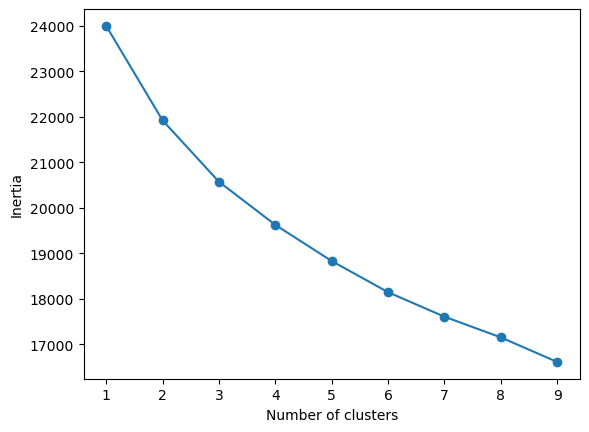

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(1,10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

* Số cụm tự nhiên: Biểu đồ Elbow Method cho thấy đồ thị có độ dốc giảm dần và tạo thành điểm gấp khúc (elbow) ở vị trí $K=3$ hoặc $K=4$. Điều này ngụ ý rằng các mẫu nước trong tự nhiên có thể được gom thành 3 đến 4 nhóm sinh thái/hóa lý có đặc tính tương đồng nhau.

CHẠY KMEANS

In [4]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

ĐÁNH GIÁ

In [5]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.07649578602541252


Silhouette Score = 0.076 cho thấy mô hình phân cụm chưa có sự tách biệt rõ ràng giữa các cụm. Giá trị gần 0 → các cụm chồng lấn nhau. Điều này là hợp lý trong dữ liệu môi trường nước

PHÂN TÍCH CỤM

In [6]:
df.groupby('Cluster').mean()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
Cluster,,,,,,,,,,
0,-0.153692,-0.037372,0.905441,-0.231726,-0.523039,0.090837,0.407896,-0.116279,0.178480,0.379808
1,0.580650,0.649268,-0.524851,-0.145109,0.147019,-0.093582,0.049852,0.184444,-0.360361,0.351380
2,-0.469844,-0.650804,-0.290266,0.369381,0.332597,0.014101,-0.433105,-0.086324,0.214086,0.390135


* Cluster 0 : Solids: cao, Organic_carbon: cao, Turbidity: hơi cao

Cụm này đại diện cho nước có hàm lượng chất rắn hòa tan cao → Không quá an toàn, cần xử lý

* Cluster 1 : pH: cao, Hardness: cao, Turbidity: thấp

Đây là cụm có các chỉ số tương đối ổn định và cân bằng

* Cluster 2 : Chloramines: cao, Sulfate: cao, Turbidity: cao, Organic_carbon: thấp

Cụm này có dấu hiệu ô nhiễm hóa học

=>Kết quả phân cụm cho thấy chất lượng nước không đồng nhất mà được chia thành các nhóm có đặc điểm hóa học khác nhau. Tuy nhiên, sự chồng lấn giữa các cụm cho thấy không tồn tại ranh giới rõ ràng giữa các loại nước. Điều này phản ánh bản chất liên tục của dữ liệu môi trường và đặt ra thách thức cho việc phân loại chính xác chất lượng nước.

2. TẠO MODEL PHÂN LOẠI

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop(['Potability', 'Cluster'], axis=1)
y = df['Potability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

TRAIN MODE LOGISTIC REGRESSION

In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [9]:
y_pred = model.predict(X_test)

In [10]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6404494382022472
              precision    recall  f1-score   support

           0       0.64      1.00      0.78       342
           1       0.00      0.00      0.00       192

    accuracy                           0.64       534
   macro avg       0.32      0.50      0.39       534
weighted avg       0.41      0.64      0.50       534



C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Mô hình Logistic Regression đạt accuracy ≈ 64%, tuy nhiên kết quả chi tiết cho thấy mô hình chỉ dự đoán đúng lớp 0 (nước không uống được) và hoàn toàn không nhận diện được lớp 1 (nước uống được), với recall của lớp 1 bằng 0.

👉 Điều này cho thấy mô hình bị ảnh hưởng bởi mất cân bằng dữ liệu, khi số lượng mẫu của hai lớp không đồng đều.

Do đó, accuracy không phải là chỉ số đánh giá phù hợp trong trường hợp này, và cần xem xét thêm các chỉ số như recall và F1-score.

DÙNG RANDOM FOREST

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced')
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.67      0.90      0.77       342
           1       0.55      0.21      0.30       192

    accuracy                           0.65       534
   macro avg       0.61      0.56      0.54       534
weighted avg       0.63      0.65      0.60       534



So với Logistic Regression, Random Forest đã cải thiện đáng kể khả năng dự đoán lớp 1 (từ 0 → 0.23 recall).

Điều này chứng tỏ: Random Forest xử lý tốt hơn dữ liệu phức tạp

Mặc dù recall của lớp 1 vẫn còn thấp (≈ 0.23), nhưng đây là một cải thiện đáng kể so với mô hình ban đầu.

Confusion Matrix

In [12]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

[[309  33]
 [152  40]]


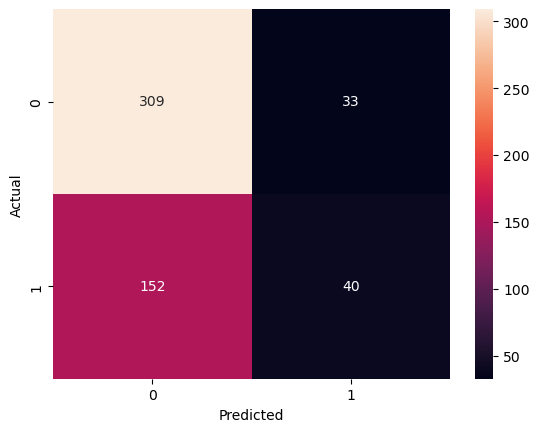

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Confusion Matrix cho thấy mô hình vẫn còn nhầm lẫn giữa hai lớp, đặc biệt là trong việc dự đoán nước uống được, phản ánh độ khó của bài toán.

Feature Importance

In [14]:
import pandas as pd

importance = rf.feature_importances_
features = X.columns

df_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

df_imp

,Feature,Importance
1,Hardness,0.124417
0,ph,0.122552
2,Solids,0.115298
3,Chloramines,0.112807
4,Sulfate,0.111438
8,Turbidity,0.104613
7,Trihalomethanes,0.103515
6,Organic_carbon,0.102828
5,Conductivity,0.102532


Các đặc trưng quan trọng nhất ảnh hưởng đến chất lượng nước là: pH, Solids, Chloramines,... Điều này phù hợp với kiến thức thực tế về các yếu tố ảnh hưởng đến nước.